# 02 — Smoothing: MA and EMA

**Stage 2** of the time-series analytics project. We smooth the
weekly/holiday noise of the daily network series (Stage 1 output)
with a simple moving average (MA) and an exponential moving
average (EMA), then fix which view answers the question
**«what is the trend once the weekly noise is gone»**.

**Status: EXPLORATORY (hypothesis-generating).** Nothing here is a
significance claim; smoothing is a descriptive read that feeds the
STL stage. Both smoothers live in `src/smoothing.py` — this
notebook only chooses windows/spans and interprets the result.


In [1]:
%matplotlib inline
import sys, pathlib
root = pathlib.Path.cwd()
while root != root.parent and not (root / 'data' / 'train.csv').exists():
    root = root.parent
if not (root / 'data' / 'train.csv').exists():
    raise FileNotFoundError('could not locate data/train.csv')
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
DATA = root / 'data' / 'train.csv'
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda v: f'{v:,.0f}')
from src.eda import load_train, daily_network_sales
from src.smoothing import simple_moving_average, exponential_moving_average
df = load_train(DATA)
daily = daily_network_sales(df)
# Same series as Stage 1: full calendar 2013-01-01..2017-08-15,
# network total per day, 0-filled only on the four Christmas days.
print(f'daily series: {len(daily)} days, '
      f"{daily.index.min().date()} .. {daily.index.max().date()}")
daily.head()

daily series: 1688 days, 2013-01-01 .. 2017-08-15


date
2013-01-01     2,512
2013-01-02   496,092
2013-01-03   361,461
2013-01-04   354,460
2013-01-05   477,350
Freq: D, Name: sales, dtype: float32

## 1. Simple moving average: windows 7 / 14 / 30

`simple_moving_average(daily, window)` uses a trailing window:
each point is the mean of exactly `window` observations, and
incomplete windows are NaN (warm-up), never partial means. Window
order = smoothing period: **7** is one full week (the weekly
rhythm found in Stage 1), **14** two weeks, **30** a roughly
monthly level.

Two summary numbers tell the trade-off: the **weekday amplitude**
(max−min of mean sales by day of week — how much weekly cycle
survives) and the **day-to-day std** (volatility left after
smoothing).

In [2]:
ma7 = simple_moving_average(daily, 7)
ma14 = simple_moving_average(daily, 14)
ma30 = simple_moving_average(daily, 30)

def weekday_amplitude(s):
    """Max-min of mean daily sales by weekday — the size of the
    weekly cycle that survives a smoothing window."""
    by_dow = s.groupby(s.index.dayofweek).mean()
    return float(by_dow.max() - by_dow.min())

summary = {}
for label, s in {'raw': daily, 'MA7': ma7, 'MA14': ma14, 'MA30': ma30}.items():
    summary[label] = {
        'weekday amplitude': weekday_amplitude(s),
        'day-to-day std': float(s.diff().std()),
        'mean': float(s.mean()),
        'last value': float(s.iloc[-1]),
    }

amp = {k: v['weekday amplitude'] for k, v in summary.items()}
vlt = {k: v['day-to-day std'] for k, v in summary.items()}
display(pd.DataFrame(summary).T)
print('weekday amplitude (raw %.0f | MA7 %.0f | MA14 %.0f | MA30 %.0f)'
      % (amp['raw'], amp['MA7'], amp['MA14'], amp['MA30']))
print('day-to-day std    (raw %.0f | MA7 %.0f | MA14 %.0f | MA30 %.0f)'
      % (vlt['raw'], vlt['MA7'], vlt['MA14'], vlt['MA30']))
print('mean level: raw %.0f | MA30 %.0f | MA30 last value %.0f'
      % (summary['raw']['mean'], summary['MA30']['mean'],
         summary['MA30']['last value']))

,weekday amplitude,day-to-day std,mean,last value
raw,"318,621","172,063","636,046","762,662"
MA7,881,"19,481","636,361","770,536"
MA14,"1,069","10,664","636,591","817,485"
MA30,"17,748","8,002","636,922","832,844"


weekday amplitude (raw 318621 | MA7 881 | MA14 1069 | MA30 17748)
day-to-day std    (raw 172063 | MA7 19481 | MA14 10664 | MA30 8002)
mean level: raw 636046 | MA30 636922 | MA30 last value 832844


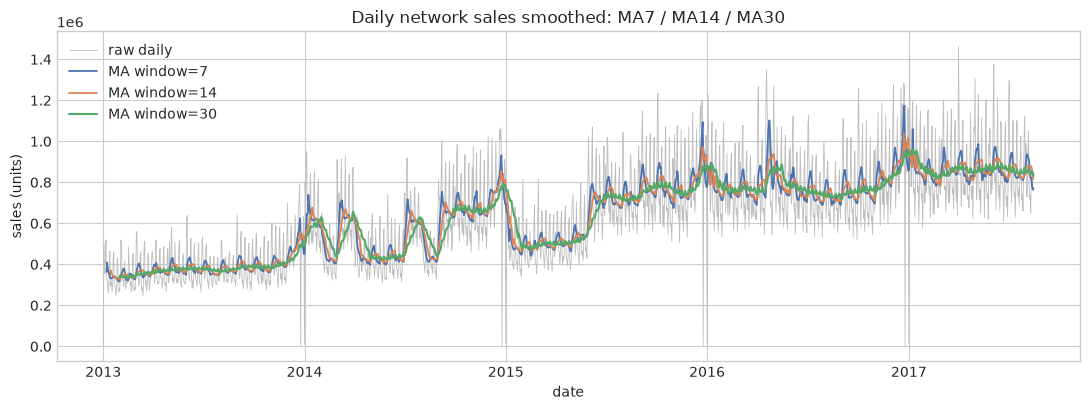

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.2))
# Raw series in thin gray is honest context: it shows exactly how
# much noise each window removes (nothing is hidden or decimated).
ax.plot(daily.index, daily.values, lw=0.6, color='0.75', label='raw daily')
ax.plot(ma7.index, ma7.values, lw=1.3, color='#4C72B0', label='MA window=7')
ax.plot(ma14.index, ma14.values, lw=1.3, color='#DD8452', label='MA window=14')
ax.plot(ma30.index, ma30.values, lw=1.5, color='#55A868', label='MA window=30')
ax.set_title('Daily network sales smoothed: MA7 / MA14 / MA30')
ax.set_xlabel('date')
ax.set_ylabel('sales (units)')
ax.legend(loc='best')
fig.tight_layout()
fig.savefig('../assets/smoothing_ma.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Exponential moving average: spans 7 / 30

`exponential_moving_average(daily, span)` runs `ewm(span=span,
adjust=False, min_periods=span)`: the decay is `alpha = 2 / (span
+ 1)`, so the mean age of the weights is `(span − 1) / 2` days
— the same average lag as an MA of `window = span`, but spread
differently: each new point enters with weight `alpha` while every
older point keeps a positive, geometrically shrinking tail.
`adjust=False` keeps the textbook recursion
`y[t] = (1 − alpha) y[t−1] + alpha x[t]`. The first `span − 1`
points are NaN (warm-up matching an MA of the same order), then the
series is gapless.

In [4]:
ema7 = exponential_moving_average(daily, 7)
ema30 = exponential_moving_average(daily, 30)
print('fidelity to raw: mean |raw − MA7| %.0f | EMA7 %.0f |'
      ' MA30 %.0f | EMA30 %.0f'
      % ((daily - ma7).abs().mean(), (daily - ema7).abs().mean(),
         (daily - ma30).abs().mean(), (daily - ema30).abs().mean()))
print('last values: MA7 %.0f | EMA7 %.0f | MA30 %.0f | EMA30 %.0f'
      % (ma7.iloc[-1], ema7.iloc[-1], ma30.iloc[-1], ema30.iloc[-1]))
print('EMA30 warm-up NaN: %d of %d; EMA7 warm-up NaN: %d of %d'
      % (int(ema30.isna().sum()), len(ema30),
         int(ema7.isna().sum()), len(ema7)))

fidelity to raw: mean |raw − MA7| 109751 | EMA7 92308 | MA30 115952 | EMA30 112850
last values: MA7 770536 | EMA7 789325 | MA30 832844 | EMA30 830565
EMA30 warm-up NaN: 29 of 1688; EMA7 warm-up NaN: 6 of 1688


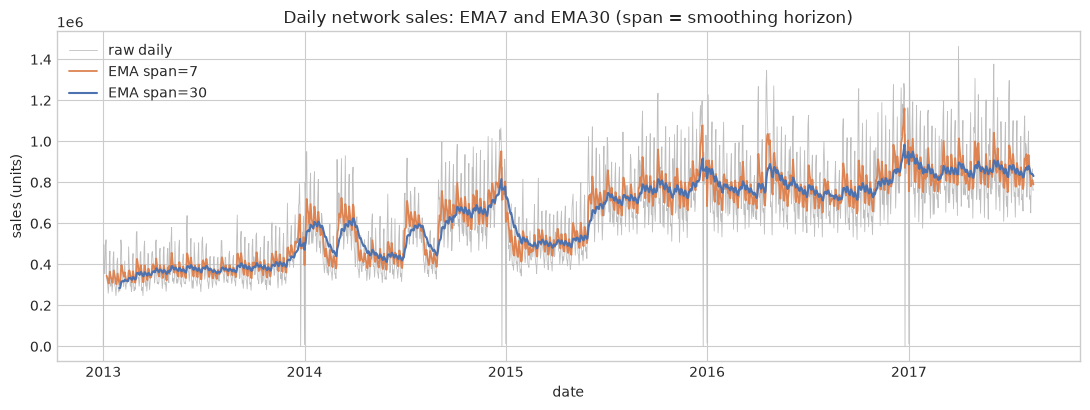

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(daily.index, daily.values, lw=0.6, color='0.75', label='raw daily')
ax.plot(ema7.index, ema7.values, lw=1.3, color='#DD8452', label='EMA span=7')
ax.plot(ema30.index, ema30.values, lw=1.5, color='#4C72B0', label='EMA span=30')
ax.set_title('Daily network sales: EMA7 and EMA30 (span = smoothing horizon)')
ax.set_xlabel('date')
ax.set_ylabel('sales (units)')
ax.legend(loc='best')
fig.tight_layout()
fig.savefig('../assets/smoothing_ema.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. MA7 vs EMA7: same order, different lag profile

Both have a mean weight age of 3 days for window/span 7, but the
weight shapes differ — MA cuts off hard after 7 days, EMA decays
forever. The empirical lag below regresses each smoother on a
back-shifted raw series (the shift that minimizes MSE is how many
days the smoother trails reality), then the final segment makes
the phase difference visible.

In [6]:
def best_lag(smoothed, raw, max_lag=10):
    """Empirical lag in days: the back-shift of *raw* that makes
    the smoother most closely track it (minimal MSE)."""
    valid = smoothed.dropna()
    best_d, best_mse = 0, float('inf')
    for d in range(max_lag + 1):
        aligned = raw.shift(d).loc[valid.index]
        mse = float(((valid - aligned) ** 2).mean())
        if mse < best_mse:
            best_d, best_mse = d, mse
    return best_d, best_mse

lag_ma7, mse_ma7 = best_lag(ma7, daily)
lag_ema7, mse_ema7 = best_lag(ema7, daily)
print('empirical lag: MA7 %d days | EMA7 %d days' % (lag_ma7, lag_ema7))
print('mean signed (EMA7 − MA7): %.1f  |  mean |EMA7 − MA7|: %.0f'
      % ((ema7 - ma7).mean(), (ema7 - ma7).abs().mean()))

empirical lag: MA7 3 days | EMA7 1 days
mean signed (EMA7 − MA7): -149.5  |  mean |EMA7 − MA7|: 30138


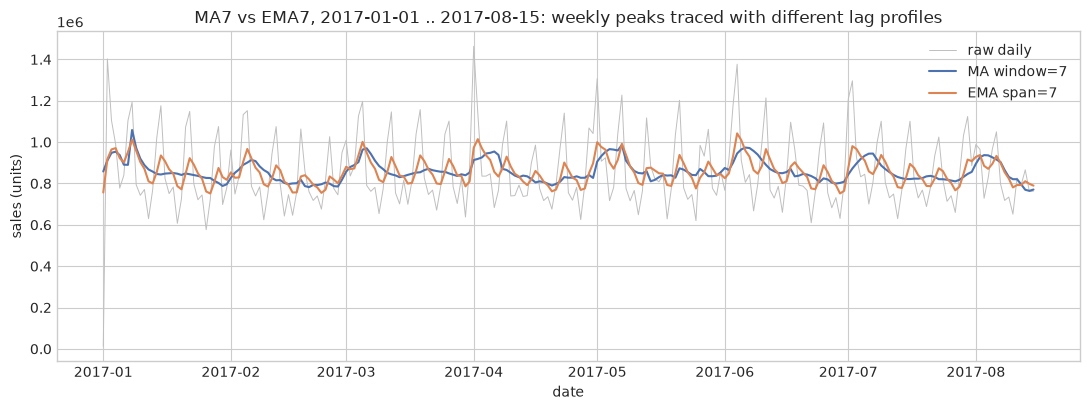

In [7]:
# A lag of 3 days is invisible at the 4.5-year scale, so compare on
# the final segment where the weekly rhythm is still strong.
zoom = slice(pd.Timestamp('2017-01-01'), pd.Timestamp('2017-08-15'))
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(daily.loc[zoom].index, daily.loc[zoom].values, lw=0.7,
        color='0.75', label='raw daily')
ax.plot(ma7.loc[zoom].index, ma7.loc[zoom].values, lw=1.5,
        color='#4C72B0', label='MA window=7')
ax.plot(ema7.loc[zoom].index, ema7.loc[zoom].values, lw=1.5,
        color='#DD8452', label='EMA span=7')
ax.set_title('MA7 vs EMA7, 2017-01-01 .. 2017-08-15: weekly peaks traced '
             'with different lag profiles')
ax.set_xlabel('date')
ax.set_ylabel('sales (units)')
ax.legend(loc='best')
fig.tight_layout()
fig.savefig('../assets/smoothing_ma_vs_ema.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Conclusion: which view answers the trend question

The weekly rhythm from Stage 1 (Sun ≈ 822k vs Thu ≈ 503k) is exactly
the noise a «trend» read must remove. Measured on the smoothed series:

| view | weekday amplitude | day-to-day std | mean level |
|---|---|---:|---:|
| raw | 318,621 | 172,063 | 636,046 |
| MA7 | 881 | 19,481 | — |
| MA14 | 1,069 | 10,664 | — |
| MA30 | 17,748 | 8,002 | 636,922 |

- **Window 7 is the answer to «trend without weekly noise».** It
  collapses the weekday amplitude from **318,621 to 881** (−99.7%)
  and the day-to-day variation from **172,063 to 19,481** (−88.7%).
  MA14 is calmer still (std 10,664) but at double the phase lag
  ((14−1)/2 vs (7−1)/2 days) — more smoothing buys you nothing for
  the weekly-cycle question, only lag.
- **Window 30 is the monthly-level read.** Its window is 30 days, not a
  multiple of 7, so a small slice of the weekly cycle leaks through
  (17,748, ~5.6% of raw) — but the level it tracks is stable: mean
  636,922 across the run, matching the raw mean 636,046, and a last
  value of 832,844. «Monthly level» rests on exactly this: a 30-day
  trailing mean is the long-run level by construction.
- **EMA7 sits closer to the observed series than MA7**: mean |raw − EMA7|
  = 92,308 vs 109,751 for MA7, and its empirical lag is **1 day vs 3**
  days. The reason is the weight shape: the newest point enters EMA with
  weight α = 1/4 against MA's equal 1/7, so EMA reacts within days
  while MA waits for the full window to turn over. The two stay on the
  same level (mean EMA7 − MA7 = −149.5; mean |EMA7 − MA7| = 30,138
  over the run) — they differ in the *shape* of response, not in where
  they point.
- **Which view to keep:** MA7 for a clean, weekly-noise-free trend read
  with a known 3-day lag (STL in stage 3 will handle the phase); EMA7 if
  the question is «where is the level *right now*» — visibly closer,
  still no weekly noise. Both warm up in 6 days; EMA30/MA30 in 29.

**Verdict:** on this network daily series, the view that answers
    «the trend without the weekly noise» is a **7-day moving average**
    (window equals the seasonal period), with EMA7 as the
    faster-responding alternative.